In [11]:
import scanpy as sc
import seaborn as sns
import os

In [12]:
mtx_dir = "../results/starsolo/run_43349135/Solo.out/Gene/filtered"

adata = sc.read_10x_mtx(
    mtx_dir,
    var_names="gene_symbols",
    cache=False
)

adata.var_names_make_unique()
adata

/Users/wangj/Documents/Computational Biology/Projects/sc-pbmc3k/sc_env/lib/python3.11/site-packages/scanpy/readwrite.py:570: UserWarning: Suffix used (-[0-9]+) to deduplicate index values may make index values difficult to interpret. There values with a similar suffixes in the index. Consider using a different delimiter by passing `join={delimiter}`. Example key collisions generated by the make_index_unique algorithm: ['SNORD116-1', 'SNORD116-2', 'SNORD116-3', 'SNORD116-4', 'SNORD116-5']
  adata = _read_10x_mtx(


AnnData object with n_obs × n_vars = 3555 × 61552
    var: 'gene_ids', 'feature_types'

In [13]:
# First step of QC: filtering low-quality cells, by three QC covariates: 
  # the number of counts per barcode (i.e., count depth)
  # the number of genes per barcode
  # the %mitochondrial genes per barcode 
# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# haemoglobin genes
adata.var["hb"] = adata.var_names.str.match(r"^HB[ABDEG]")

# Calculate the respective QC metrics with Scanpy.
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], 
    inplace=True, # "inplace" modifies the data directly, without making an extra copy that will take up more space.
    percent_top=[20], # "percent_top=[20]" asks: what percentage of the cell's total reads is taken up the top 20 most abundant genes.
    log1p=True # "log1p=True" calculates log(1+x) for the total counts, as the data is often skewed. 
)
adata

AnnData object with n_obs × n_vars = 3555 × 61552
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

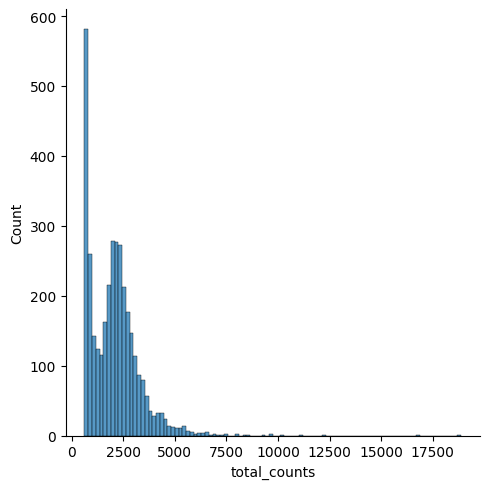

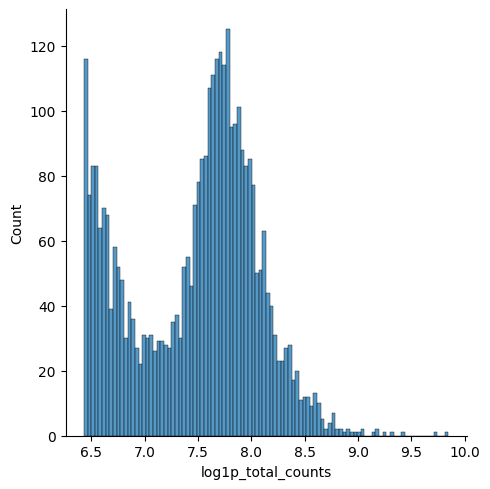

In [14]:
# the sequencing depth across all cells.
# "Kernel Density Estimate" (smooth line) is turned off.
p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)
p1_log1p = sns.displot(adata.obs["log1p_total_counts"], bins=100, kde=False)

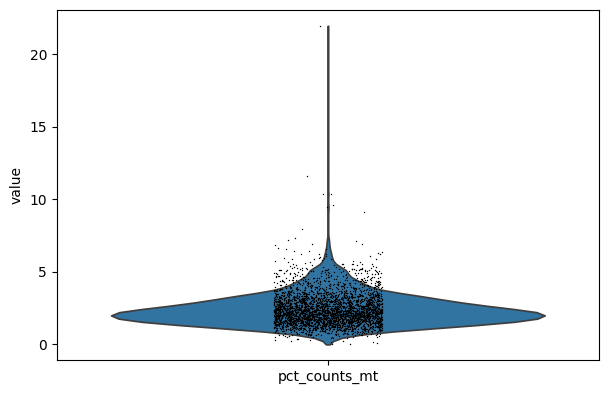

In [15]:
# %mitochondrial genes & range across all cells. 
# "pct_counts_mt" is the %mitochondrial genes.
# Healthy cells have <5%.
p2 = sc.pl.violin(adata, "pct_counts_mt")

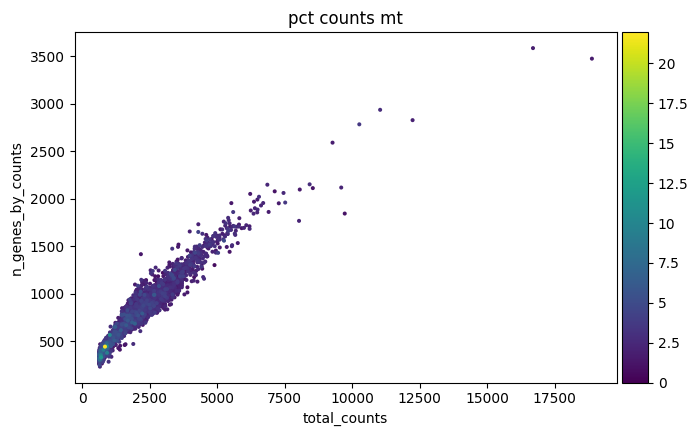

In [16]:
# Complexity of the read library, shown as total_counts versus n_genes_by_counts (the number of unique genes).
# We expect a diagonal line.
# By colouring points by %mitochondrial genes, it becomes obvious that dying cells have lowest gene counts.
p3 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [17]:
# Save adata as a checkpoint.
processed_data_path = "../data/processed"
os.makedirs(processed_data_path, exist_ok=True)

adata.write_h5ad(f"{processed_data_path}/01_load_qc.h5ad")